# Punto 2 — SVM: teoría y aplicación con datos del USGS
**Guía:** José J. Martínez P., *Introducción a Machine Learning*, septiembre de 2026, sección 6.12, ejercicio 2. **Base revisada:** notebook `SVM(2).ipynb`.

**Objetivo:** explicar SVM, mejorar la documentación y adaptarlo a una aplicación con datos gubernamentales. Clasificaremos registros de sismos en dos grupos: profundidad **menor de 70 km** y **70 km o más**, usando ubicación y magnitud. Es un ejercicio de clasificación retrospectiva, no una predicción de futuros sismos ni de peligrosidad.

**Colab:** Archivo → Subir notebook → Entorno de ejecución → Ejecutar todas. No necesitas GPU ni subir un CSV: se incluye una copia de los datos oficiales utilizados.

## 1. ¿Cómo funciona SVM?
SVM (*Support Vector Machine*) es aprendizaje supervisado: recibe entradas y etiquetas conocidas para aprender una frontera entre clases. En dos dimensiones, la frontera lineal es una recta; en más dimensiones, un hiperplano:

$$f(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b$$

En clasificación binaria, el signo de $f$ determina la clase. Para la formulación matemática usamos etiquetas $y_i\in\{-1,+1\}$; en el código serán 0 y 1.

SVM busca un **margen amplio** entre las clases. Las fronteras del margen son $f=+1$ y $f=-1$, cuya separación es $2/\|\mathbf{w}\|$. Los **vectores de soporte** son ejemplos con coeficientes duales no nulos que participan en la definición de la frontera; pueden estar sobre el margen o violarlo. No es necesario guardar todos los ejemplos para evaluar la función de decisión.

### Margen flexible y parámetro C
Con ruido o solapamiento, se permiten violaciones del margen mediante variables $\xi_i$:

$$\min_{\mathbf{w},b,\xi}\;\frac{1}{2}\|\mathbf{w}\|^2+C\sum_i\xi_i$$

$$y_i(\mathbf{w}^{T}\mathbf{x}_i+b)\geq1-\xi_i,\qquad\xi_i\geq0$$

Un **C grande** penaliza más las violaciones; un **C pequeño** permite más violaciones y favorece regularización. Un valor grande puede sobreajustar. La pérdida asociada es *hinge loss*: $\max(0,1-y_i f(\mathbf{x}_i))$. Los valores atípicos pueden alterar la frontera, sobre todo con poca regularización.

### Kernels y escalamiento
El kernel permite comparar ejemplos como si estuvieran transformados a otro espacio sin construir todas sus nuevas coordenadas:

| Kernel | Expresión | Idea |
|---|---|---|
| Lineal | $K(\mathbf{x},\mathbf{z})=\mathbf{x}^{T}\mathbf{z}$ | Frontera lineal en las características usadas. |
| Polinómico | $(\gamma\mathbf{x}^{T}\mathbf{z}+r)^d$ | Interacciones de grado $d$. |
| RBF | $\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ | Frontera flexible basada en proximidad. |

En RBF, **gamma grande** hace que cada ejemplo influya en una zona más pequeña; gamma pequeño produce una influencia más amplia. Se debe elegir junto con C usando validación, no el conjunto final de prueba.

La función de decisión usa los vectores de soporte:

$$f(\mathbf{x})=\sum_{i\in SV}\alpha_i y_i K(\mathbf{x}_i,\mathbf{x})+b$$

SVM es sensible a las escalas. `StandardScaler` aplica $z=(x-\mu)/\sigma$, aprendiendo media y desviación solo del entrenamiento. `Pipeline` mantiene este proceso dentro de cada partición de validación.

**Otras variantes del notebook base:** `LinearSVC` es una implementación especializada en clasificación lineal; `SVC` permite kernels y utiliza comparaciones por parejas para múltiples clases. `SVR` predice números y emplea un tubo de tolerancia $\epsilon$; aquí usamos `SVC` porque la salida es una categoría. El valor de `decision_function` es un puntaje, no una probabilidad calibrada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from time import perf_counter
import base64, zlib, io, hashlib


## 2. Visualizar la diferencia entre una frontera lineal y RBF
Conservamos la idea de las dos lunas del notebook base. Estos datos **sintéticos** son únicamente una demostración visual; las métricas de la aplicación se calcularán con los registros oficiales. Los círculos resaltan los vectores de soporte. No se fija semilla, por lo que esta demostración cambia al ejecutarla.

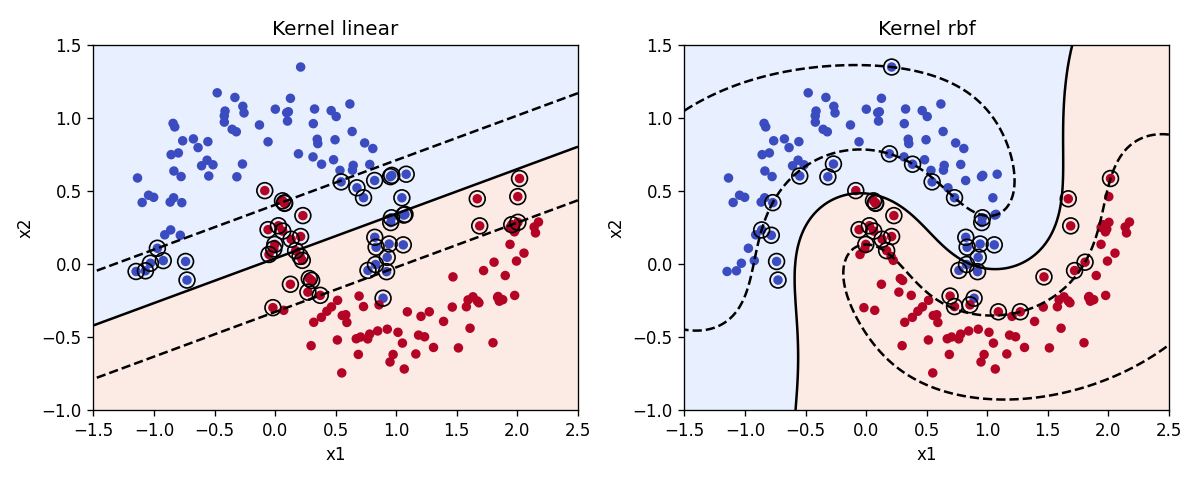

In [2]:
X_demo, y_demo = make_moons(n_samples=180, noise=0.15)
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 150), np.linspace(-1, 1.5, 150))
malla = np.column_stack((xx.ravel(), yy.ravel()))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, kernel in zip(axes, ['linear', 'rbf']):
    demo = Pipeline([('escala', StandardScaler()), ('svm', SVC(kernel=kernel, C=1))])
    demo.fit(X_demo, y_demo)
    puntajes = demo.decision_function(malla).reshape(xx.shape)
    ax.contourf(xx, yy, puntajes > 0, levels=[-0.5, 0.5, 1.5],
                cmap='coolwarm', alpha=0.2)
    ax.contour(xx, yy, puntajes, levels=[-1, 0, 1], colors='black',
               linestyles=['--', '-', '--'])
    ax.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap='coolwarm', s=22)
    soportes = X_demo[demo['svm'].support_]
    ax.scatter(soportes[:, 0], soportes[:, 1], s=90, facecolors='none', edgecolors='black')
    ax.set(title=f'Kernel {kernel}', xlabel='x1', ylabel='x2')
plt.tight_layout(); plt.show()
# En RBF, los contornos ±1 no representan un ancho euclidiano constante en el plano.


## 3. Datos de la entidad gubernamental
**Fuente:** catálogo del U.S. Geological Survey (USGS), servicio geológico del Gobierno de Estados Unidos. Consulta realizada el **4 de octubre de 2026**.

Se solicitaron los primeros **3.000 eventos**, ordenados cronológicamente, de una búsqueda mundial desde el 1 de enero de 2025 hasta el 1 de enero de 2026, con magnitud mínima 4. El límite se alcanza el **5 de marzo de 2025**: esta muestra **no representa el año completo**. Conservamos sismos (`type == earthquake`) y quitamos duplicados por identificador.

[Consulta original (CSV)](https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2025-01-01&endtime=2026-01-01&minmagnitude=4&orderby=time-asc&limit=3000) · [Documentación de la API](https://earthquake.usgs.gov/fdsnws/event/1/)

La celda siguiente contiene una copia comprimida con las columnas necesarias, para funcionar sin descargas. Se documenta su SHA-256 para identificar los bytes utilizados. El catálogo puede recibir revisiones; una descarga posterior puede cambiar. Por defecto usamos la copia incluida; cambia `ACTUALIZAR_DESDE_USGS` a `True` si deseas descargar nuevamente.

In [3]:
# Copia de los datos oficiales; la compresión solo reduce el tamaño del notebook.
URL_USGS = 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2025-01-01&endtime=2026-01-01&minmagnitude=4&orderby=time-asc&limit=3000'
SHA256_COPIA = '5bd0b73d5c0d5922eaf2abef1a483c37b4dea49706e9e980140123b0d12e593c'
COPIA_COMPRIMIDA = '...'
ACTUALIZAR_DESDE_USGS = False

csv_bytes = zlib.decompress(base64.b64decode(COPIA_COMPRIMIDA))
assert hashlib.sha256(csv_bytes).hexdigest() == SHA256_COPIA
if ACTUALIZAR_DESDE_USGS:
    from urllib.request import urlopen
    with urlopen(URL_USGS, timeout=60) as respuesta:
        csv_bytes = respuesta.read()
datos = pd.read_csv(io.BytesIO(csv_bytes))
print('Registros cargados:', len(datos))
display(datos.head())


Registros cargados: 3000


time,id,latitude,longitude,mag,depth,type
2025-01-01T00:13:22.650Z,us6000pjr6,12.7441,143.6244,4.2,35.000,earthquake
2025-01-01T01:00:50.839Z,us6000pgrt,34.6287,16.5823,4.0,10.000,earthquake
2025-01-01T01:07:10.492Z,us6000pgru,-5.9077,128.8869,4.4,277.355,earthquake
2025-01-01T01:46:59.538Z,us6000pjqz,-3.8682,151.6536,4.7,10.000,earthquake
2025-01-01T02:00:06.918Z,us6000pjr1,-3.8521,151.6207,4.5,10.000,earthquake


## 4. Preparar entradas y etiquetas
La etiqueta es una **agrupación binaria didáctica** definida por el umbral de 70 km: 0 = menor de 70; 1 = 70 o más. No equivale a una categoría de peligrosidad.

La profundidad crea la etiqueta, pero **no entra al modelo**. Usarla como entrada resolvería directamente la regla y falsearía la evaluación. Tampoco usamos identificadores ni fecha como predictores.

Representamos latitud y longitud mediante tres coordenadas sobre una esfera unitaria. Así evitamos tratar −180° y +180° como lugares lejanos. Añadimos magnitud como cuarta característica. Eliminamos registros sin ubicación, magnitud o profundidad: imprimimos cuántos se excluyeron. La fecha sirve para ordenar las particiones.

In [4]:
variables = ['latitude', 'longitude', 'mag', 'depth']
antes = len(datos)
limpios = datos.loc[datos['type'].eq('earthquake')].drop_duplicates('id').copy()
for col in variables:
    limpios[col] = pd.to_numeric(limpios[col], errors='coerce')
limpios['time'] = pd.to_datetime(limpios['time'], utc=True, errors='coerce')
limpios = limpios.replace([np.inf, -np.inf], np.nan).dropna(subset=variables + ['time'])
limpios = limpios.sort_values('time').reset_index(drop=True)
print('Registros excluidos:', antes - len(limpios))
print('Periodo conservado:', limpios.time.min(), 'a', limpios.time.max())

lat = np.deg2rad(limpios['latitude'])
lon = np.deg2rad(limpios['longitude'])
X = pd.DataFrame({'geo_x': np.cos(lat)*np.cos(lon),
                  'geo_y': np.cos(lat)*np.sin(lon),
                  'geo_z': np.sin(lat), 'magnitud': limpios['mag']})
y = (limpios['depth'] >= 70).astype(int)
etiquetas = ['Menor de 70 km', '70 km o más']
display(pd.DataFrame({'Cantidad': y.value_counts().sort_index(),
                      'Porcentaje': y.value_counts(normalize=True).sort_index()*100}))
print('Entradas:', list(X.columns), '| Salida: categoría de profundidad')
assert 'depth' not in X.columns


Registros excluidos: 0
Periodo conservado: 2025-01-01 00:13:22.650000+00:00 a 2025-03-05 13:53:32.427000+00:00
Entradas: ['geo_x', 'geo_y', 'geo_z', 'magnitud'] | Salida: categoría de profundidad


Cantidad,Porcentaje
2206,73.533333
794,26.466667


## 5. Separación temporal y validación
Reservamos el último 20 % de registros para prueba. Dentro del 80 % inicial, `TimeSeriesSplit` crea tres particiones con entrenamiento anterior a validación. Los bloques contienen cantidades similares de eventos, pero no necesariamente la misma duración. La selección usa **F1 macro**, que pondera por igual las dos clases; `class_weight='balanced'` aumenta el peso de la clase menos frecuente en el entrenamiento.

El conjunto de prueba se consulta después de elegir los parámetros. Esta separación reduce la mezcla de eventos cercanos en el tiempo, aunque no elimina las dependencias entre réplicas ni sustituye una evaluación en otros periodos o regiones.

In [5]:
corte = int(0.80 * len(X))
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
print('Entrenamiento:', len(X_train), '| Prueba:', len(X_test))
print('Último evento de entrenamiento:', limpios.time.iloc[corte-1])
print('Primer evento de prueba:', limpios.time.iloc[corte])
cv = TimeSeriesSplit(n_splits=3)
for i, (tr, va) in enumerate(cv.split(X_train), 1):
    assert y_train.iloc[tr].nunique() == 2
    print(f'Partición {i}: {len(tr)} para aprender; {len(va)} para validar')


Entrenamiento: 2400 | Prueba: 600
Último evento de entrenamiento: 2025-02-18 06:45:19.931000+00:00
Primer evento de prueba: 2025-02-18 07:38:13.090000+00:00
Partición 1: 600 para aprender; 600 para validar
Partición 2: 1200 para aprender; 600 para validar
Partición 3: 1800 para aprender; 600 para validar


## 6. Comparar kernels y elegir parámetros
Probamos tres valores de C con kernel lineal y cuatro combinaciones C–gamma para RBF. `GridSearchCV` entrena y valida cada combinación; luego vuelve a entrenar la mejor con todo el bloque inicial. La estandarización se aprende nuevamente dentro de cada partición. Los parámetros de la búsqueda son decisiones del ejercicio, no valores universalmente óptimos.

In [6]:
pipeline = Pipeline([('escala', StandardScaler()),
                     ('svm', SVC(class_weight='balanced'))])
parametros = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
    {'svm__kernel': ['rbf'], 'svm__C': [1, 10], 'svm__gamma': ['scale', 1]}
]
busqueda = GridSearchCV(pipeline, parametros, cv=cv, scoring='f1_macro',
                       n_jobs=1, return_train_score=True)
inicio = perf_counter()
busqueda.fit(X_train, y_train)
tiempo_busqueda = perf_counter() - inicio
modelo = busqueda.best_estimator_
resultados_cv = pd.DataFrame({
    'Parámetros': busqueda.cv_results_['params'],
    'F1 entrenamiento': busqueda.cv_results_['mean_train_score'],
    'F1 validación': busqueda.cv_results_['mean_test_score'],
    'Desviación validación': busqueda.cv_results_['std_test_score']
}).sort_values('F1 validación', ascending=False)
display(resultados_cv)
print('Mejores parámetros:', busqueda.best_params_)
print(f'F1 macro de validación: {busqueda.best_score_:.3f}')
print(f'Tiempo de búsqueda y ajuste: {tiempo_busqueda:.2f} s')
print('Vectores de soporte por clase:', modelo['svm'].n_support_)


Mejores parámetros: {'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
F1 macro de validación: 0.713
Tiempo de búsqueda y ajuste: 1.29 s
Vectores de soporte por clase: [862 287]


Parámetros,F1 entrenamiento,F1 validación,Desviación validación
"{'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}",0.772344,0.713292,0.033864
"{'svm__C': 10, 'svm__gamma': 1, 'svm__kernel': 'rbf'}",0.806176,0.707450,0.017570
"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}",0.746990,0.697198,0.032424
"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}",0.711420,0.649952,0.053430
"{'svm__C': 10, 'svm__kernel': 'linear'}",0.662212,0.644523,0.012306
"{'svm__C': 1, 'svm__kernel': 'linear'}",0.663174,0.643191,0.013239
"{'svm__C': 0.1, 'svm__kernel': 'linear'}",0.665371,0.639202,0.015448


## 7. Evaluación final y comparación con una referencia sencilla
La referencia siempre predice la clase mayoritaria aprendida en entrenamiento. Superarla ayuda a comprobar que el modelo aporta algo más que aprovechar el desbalance.

- **Accuracy (exactitud):** proporción total de aciertos; puede ocultar fallos en la clase menos frecuente.
- **Precision de una clase:** de lo predicho como esa clase, cuánto es correcto.
- **Recall de una clase:** de los casos reales de esa clase, cuántos se detectan.
- **F1:** $2PR/(P+R)$, combina precision y recall. **F1 macro** promedia los F1 de ambas clases.
- **Balanced accuracy:** promedio de los recalls de las dos clases.

En la matriz de confusión, las filas son clases reales y las columnas son predicciones. La diagonal son aciertos. Si la clase positiva es “70 km o más”, la celda inferior izquierda son falsos negativos y la superior derecha, falsos positivos.

                precision    recall  f1-score   support

Menor de 70 km      0.854     0.523     0.649       390
   70 km o más      0.485     0.833     0.613       210

      accuracy                          0.632       600
     macro avg      0.669     0.678     0.631       600
  weighted avg      0.724     0.632     0.636       600



Modelo,Accuracy,Balanced accuracy,F1 macro
Clase mayoritaria,0.650000,0.500000,0.393939
SVM seleccionado,0.631667,0.678205,0.630804


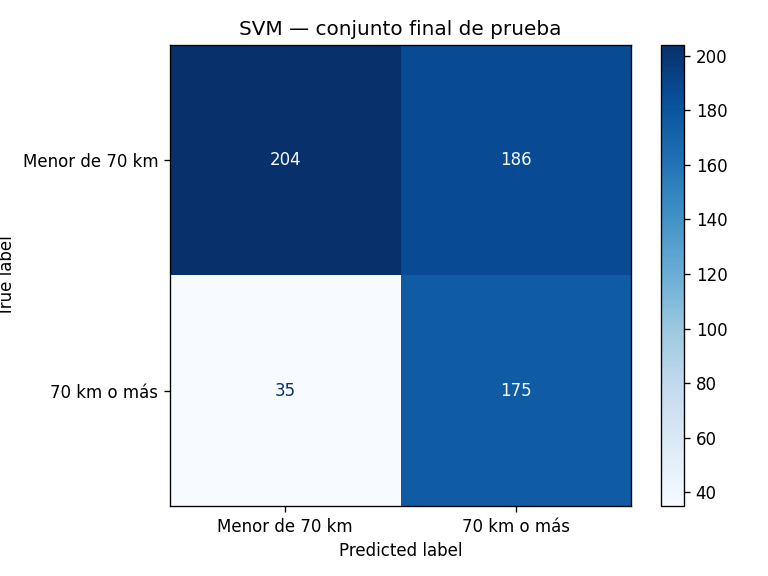

In [7]:
pred = modelo.predict(X_test)
referencia = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_base = referencia.predict(X_test)
metricas = []
for nombre, estimacion in [('Clase mayoritaria', pred_base), ('SVM seleccionado', pred)]:
    metricas.append({'Modelo': nombre, 'Accuracy': accuracy_score(y_test, estimacion),
                     'Balanced accuracy': balanced_accuracy_score(y_test, estimacion),
                     'F1 macro': f1_score(y_test, estimacion, average='macro', zero_division=0)})
display(pd.DataFrame(metricas))
print(classification_report(y_test, pred, labels=[0, 1], target_names=etiquetas,
                            digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=[0, 1],
                                        display_labels=etiquetas, cmap='Blues')
plt.title('SVM — conjunto final de prueba'); plt.tight_layout(); plt.show()


## 8. Revisar diez predicciones y los errores
Estos diez casos pertenecen al bloque final reservado: el modelo no los utilizó para entrenar ni para elegir parámetros. El puntaje de decisión positivo corresponde a la clase 1; su magnitud no se interpreta como una probabilidad.

La profundidad se muestra **después** de predecir, únicamente para comprobar la respuesta. También listamos errores para analizar cuáles se producen cerca del umbral y cuáles se alejan de él.

In [8]:
comparacion = limpios.iloc[corte:].copy()
comparacion['Clase real'] = [etiquetas[v] for v in y_test]
comparacion['Clase predicha'] = [etiquetas[v] for v in pred]
comparacion['Acierto'] = y_test.to_numpy() == pred
comparacion['Puntaje SVM'] = modelo.decision_function(X_test)
columnas = ['time', 'latitude', 'longitude', 'mag', 'depth',
            'Clase real', 'Clase predicha', 'Acierto', 'Puntaje SVM']
display(comparacion[columnas].head(10))
errores = comparacion.loc[~comparacion['Acierto']]
print('Errores en prueba:', len(errores), 'de', len(y_test))
display(errores[columnas].head(10))
print(f'F1 entrenamiento completo: {f1_score(y_train, modelo.predict(X_train), average="macro"):.3f}')
print(f'F1 prueba: {f1_score(y_test, pred, average="macro"):.3f}')


Errores en prueba: 221 de 600
F1 entrenamiento completo: 0.759
F1 prueba: 0.631


time,latitude,longitude,mag,depth,Clase real,Clase predicha,Acierto,Puntaje SVM
2025-02-18 07:38:13.090000+00:00,-62.8512,151.3674,4.8,10.0000,Menor de 70 km,Menor de 70 km,True,-1.674034
2025-02-18 09:08:47.148000+00:00,-10.8343,-76.9160,4.4,90.8700,70 km o más,70 km o más,True,0.846908
2025-02-18 09:24:09.405000+00:00,34.2658,26.2083,4.2,51.1360,Menor de 70 km,Menor de 70 km,True,-1.372604
2025-02-18 12:13:40.337000+00:00,-4.3605,153.0154,4.7,10.0000,Menor de 70 km,Menor de 70 km,True,-0.628423
2025-02-18 12:16:28.873000+00:00,31.7110,-104.5020,4.7,3.8953,Menor de 70 km,Menor de 70 km,True,-1.270474
2025-02-18 12:24:36.264000+00:00,-4.5088,125.4556,4.0,436.2890,70 km o más,70 km o más,True,1.163097
2025-02-18 12:40:59.641000+00:00,39.1494,17.1040,4.3,32.9620,Menor de 70 km,Menor de 70 km,True,-0.770835
2025-02-18 13:39:19.561000+00:00,-49.5159,122.5703,4.5,10.0000,Menor de 70 km,Menor de 70 km,True,-1.348737
2025-02-18 13:43:48.365000+00:00,36.5155,25.8175,4.0,10.0000,Menor de 70 km,Menor de 70 km,True,-1.133061
2025-02-18 14:26:55.191000+00:00,11.4590,125.6197,4.2,10.0000,Menor de 70 km,70 km o más,False,0.596762


time,latitude,longitude,mag,depth,Clase real,Clase predicha,Acierto,Puntaje SVM
2025-02-18 14:26:55.191000+00:00,11.4590,125.6197,4.2,10.000,Menor de 70 km,70 km o más,False,0.596762
2025-02-18 15:24:28.025000+00:00,-14.9641,-173.1341,4.5,10.000,Menor de 70 km,70 km o más,False,0.890960
2025-02-18 19:29:32.909000+00:00,-11.9362,112.3134,4.3,10.000,Menor de 70 km,70 km o más,False,0.735777
2025-02-18 20:40:41.101000+00:00,10.2469,-85.6806,4.3,32.248,Menor de 70 km,70 km o más,False,0.021013
2025-02-18 23:39:10.674000+00:00,-3.3656,131.0386,5.7,13.000,Menor de 70 km,70 km o más,False,0.339825
2025-02-19 00:01:03.300000+00:00,-3.2245,131.0111,4.3,10.000,Menor de 70 km,70 km o más,False,1.136052
2025-02-19 02:49:24.518000+00:00,-26.2998,-70.7683,4.1,26.203,Menor de 70 km,70 km o más,False,0.920996
2025-02-19 04:38:05.820000+00:00,-3.4351,131.0349,4.8,10.000,Menor de 70 km,70 km o más,False,0.857239
2025-02-19 05:40:17.102000+00:00,-26.2255,-71.0697,4.1,19.180,Menor de 70 km,70 km o más,False,0.909303
2025-02-19 06:46:16.408000+00:00,-19.3516,-70.1333,4.3,57.272,Menor de 70 km,70 km o más,False,1.229512


## 9. Cambios respecto al notebook SVM original
| Elemento | Adaptación realizada |
|---|---|
| Iris y ejemplos generales | Aplicación binaria con registros gubernamentales del USGS. |
| Documentación mayormente en inglés | Explicación en español de margen, C, kernels, gamma, escalamiento y métricas. |
| Gráficas de entrenamiento | Se conserva una demostración de fronteras y se añade evaluación separada. |
| Parámetros fijados a mano | Búsqueda con validación temporal, sin usar prueba para seleccionar. |
| Dos medidas de pétalos | Ubicación esférica y magnitud; profundidad excluida de las entradas. |
| Sin evaluación final de la aplicación | Referencia mayoritaria, F1 macro, reporte por clase, matriz y análisis de errores. |

Se usa `SVC` de scikit-learn en lugar de reutilizar la implementación manual del notebook base: esto mantiene el ejercicio centrado en estudiar, adaptar y evaluar el algoritmo.

## 10. Interpretación, costo y límites
Lee primero el F1 de validación para entender por qué se eligió el kernel. Después compara F1 macro y balanced accuracy de prueba con la referencia mayoritaria. Revisa por separado el recall de “70 km o más”: una exactitud alta no garantiza que esta clase se detecte bien.

Una diferencia grande entre entrenamiento y validación/prueba puede sugerir sobreajuste o cambios en la distribución; no lo demuestra por sí sola. Un resultado modesto también es informativo: ubicación y magnitud no determinan de manera única la profundidad.

**Costo:** entrenar `SVC` con kernels puede volverse costoso al aumentar los ejemplos. Para RBF, predecir un caso requiere comparar sus características con los vectores de soporte; más soportes suelen aumentar ese trabajo. La búsqueda realiza 21 ajustes de validación y un ajuste final, y muestra su tiempo. Para datasets muy grandes se podrían estudiar métodos lineales o aproximaciones del kernel.

**Alcance:** son los primeros 3.000 eventos de la consulta, no una muestra representativa de todos los sismos. Los eventos cercanos pueden estar relacionados; las magnitudes pueden provenir de escalas distintas. Las características esféricas representan posición, no estructura geológica. Los registros tienen incertidumbre en profundidad y pueden revisarse. La etiqueta agrupa por un umbral elegido para el ejercicio. El modelo clasifica registros dentro de este experimento; no calcula el momento, la magnitud ni el daño de un sismo futuro.

**Para el informe:** registra el kernel y parámetros seleccionados, cantidad final de registros, distribución de clases, F1 macro y balanced accuracy en prueba, y errores de la matriz. Explica si supera la referencia y qué limitaciones impiden generalizar. Usa los valores de tu ejecución sin presentar las métricas de entrenamiento como resultados finales.

## Referencias
[1] J. J. Martínez P., *Introducción a Machine Learning*, material de clase, sep. 2026, sección 6.12.

[2] Notebook suministrado *SVM(2).ipynb*. Fuente enlazada en el archivo: [Support Vector Machines](https://github.com/jbagnato/handson-ml/blob/master/05_support_vector_machines.ipynb).

[3] U.S. Geological Survey, [Earthquake Catalog — API Documentation](https://earthquake.usgs.gov/fdsnws/event/1/), consulta: 4 oct. 2026. La URL exacta y los filtros están en la sección 3.

[4] Scikit-learn developers, [Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html), consulta: 4 oct. 2026.

[5] Scikit-learn developers, [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), consulta: 4 oct. 2026.
